# Generación de Espectros de Transmisión con POSEIDON
En este notebook calcularemos y compararemos los espectros de transmisión de la Tierra y TRAPPIST-1e para distintos escenarios de agricultura.

In [13]:
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_E, M_E

#***** Define stellar properties *****#

R_s = 1*R_Sun   # Stellar radius (m)
T_s = 5778.0          # Stellar effective temperature (K)
Met_s = 0.0           # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.44        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s)

#***** Define planet properties *****#

planet_name = 'Earth'  # Planet name used for plots, output files etc.

R_p = 1*R_E     # Planetary radius (m)
M_p = 1*M_E       # Planetary mass (kg)
T_eq = 255.0           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

In [26]:
from POSEIDON.core import define_model
import numpy as np

#***** Define models *****#

model_name_1 = 'Earth_A0_PreAgri'   # First model
model_name_2 = 'Earth_A1_Current'  # Second model
model_name_3 = 'Earth_A2_Moderate' # Third model
model_name_4 = 'Earth_A3_Extreme'  # Fourth model

bulk_species = ['N2']                                      # For terrestrial planets, only the single most abundant gas should be provided here
param_species = ['H2O', 'CO2', 'CH4', 'O2', 'O3', 'N2O']

# Create the model objects
model_1 = define_model(model_name_1, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)
model_2 = define_model(model_name_2, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)
model_3 = define_model(model_name_3, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)
model_4 = define_model(model_name_4, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)

#***** Create model pressure grid (same for both models) *****#

# Specify the pressure grid of the atmosphere
P_min = 1.0e-10    # 0.1 ubar
P_max = 10.0      # 10 bar (you can extend the atmosphere deeper than the surface)
N_layers = 100    # 100 layers

P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Add the surface pressure
P_surf = 1.0      # Effectively acts as a cloud deck opaque at all wavelengths

# Specify the reference pressure and radius
P_ref = P_surf    # We'll set the reference pressure at the surface
R_p_ref = R_p     # Radius at reference pressure

In [27]:
from POSEIDON.utility import read_PT_file

# Specify location of the P-T profile file
PT_file_dir = '../profiles/'  # Directory containing the P-T profile files
PT_file_name_1 = 'Earth_A0_PreAgri_PT.txt'
PT_file_name_2 = 'Earth_A1_Current_PT.txt'
PT_file_name_3 = 'Earth_A2_Moderate_PT.txt'
PT_file_name_4 = 'Earth_A3_Extreme_PT.txt'

# Read the P-T profile files
T_Modern = read_PT_file(PT_file_dir, PT_file_name_1, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_Archean = read_PT_file(PT_file_dir, PT_file_name_2, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_Moderate = read_PT_file(PT_file_dir, PT_file_name_3, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_Extreme = read_PT_file(PT_file_dir, PT_file_name_4, P, skiprows = 1,
                        P_column = 2, T_column = 3)

In [28]:
from POSEIDON.utility import read_chem_file

# Specify location of the composition file
chem_file_dir = '../profiles/'  # Directory containing the composition files
chem_file_name_1 = 'Earth_A0_PreAgri_chem.txt'
chem_file_name_2 = 'Earth_A1_Current_chem.txt'
chem_file_name_3 = 'Earth_A2_Moderate_chem.txt'
chem_file_name_4 = 'Earth_A3_Extreme_chem.txt'


chem_species_file = [
    'OH', 'H2', 'H2O', 'H', 'O', 'CH', 'C', 'CH2', 'CH3', 'CH4',
    'C2', 'C2H2', 'C2H', 'C2H3', 'C2H4', 'C2H5', 'C2H6',
    'CO', 'CO2', 'CH2OH', 'H2CO', 'HCO', 'CH3O', 'CH3OH', 'CH3CO',
    'O2', 'H2CCO', 'HCCO', 'CH3O2', 'HO2', 'CH3OOH',
    'N', 'NH', 'CN', 'HCN', 'NH2', 'N2', 'NH3', 'NO',
    'N2H2', 'N2H', 'N2H3', 'N2H4', 'HNO', 'H2CN', 'HNCO', 'NO2', 'N2O',
    'C4H2', 'CH2NH2', 'CH2NH', 'CH3NH2', 'CH3CHO',
    'O3', 'NO3', 'HNO3', 'HNO2', 'NCO', 'N2O5',
    'S', 'SH', 'S2', 'SO', 'H2S', 'CS', 'COS', 'CS2', 'NS', 'HS2', 'SO2',
    'S4', 'S8', 'HCS', 'S3', 'H2O2', 'SO3', 'HSO3', 'HSO', 'H2SO4',
    'HC3N', 'CH3CN', 'CH2CN', 'C2H3CN', 'CH3SH', 'CH3S',
    'C3H3', 'C3H2', 'C3H4', 'C6H5', 'C6H6', 'C4H3', 'C4H5',
    'S2O', 'O_1', 'CH2_1', 'N_2D', 'He', 'H2O_l_s', 'H2SO4_l'
]
# Read the composition files
X_A0 = read_chem_file(chem_file_dir, chem_file_name_1, P, chem_species_file,
                          chem_species_in_model = model_1['chemical_species'],
                          skiprows = 1)
X_A1 = read_chem_file(chem_file_dir, chem_file_name_2, P, chem_species_file,
                           chem_species_in_model = model_2['chemical_species'],
                           skiprows = 1)
X_A2 = read_chem_file(chem_file_dir, chem_file_name_3, P, chem_species_file,
                           chem_species_in_model = model_3['chemical_species'],
                           skiprows = 1)
X_A3 = read_chem_file(chem_file_dir, chem_file_name_4, P, chem_species_file,
                           chem_species_in_model = model_4['chemical_species'],
                           skiprows = 1) 


In [29]:
X_A0.shape

(7, 100)

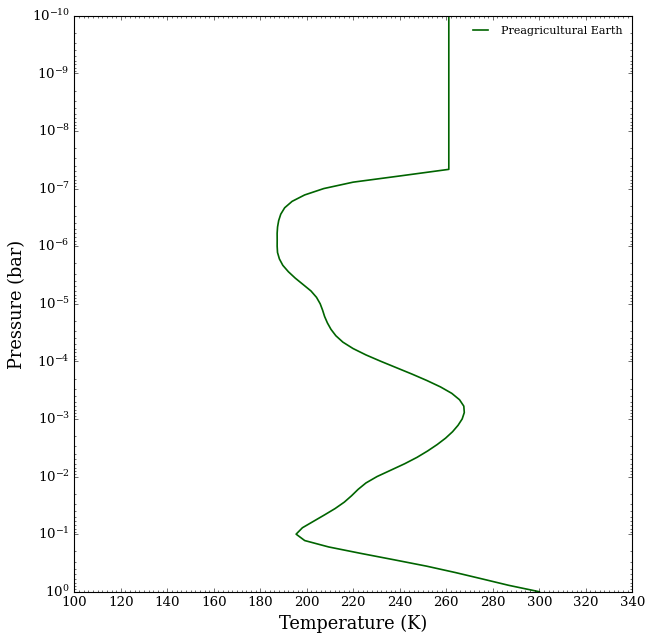

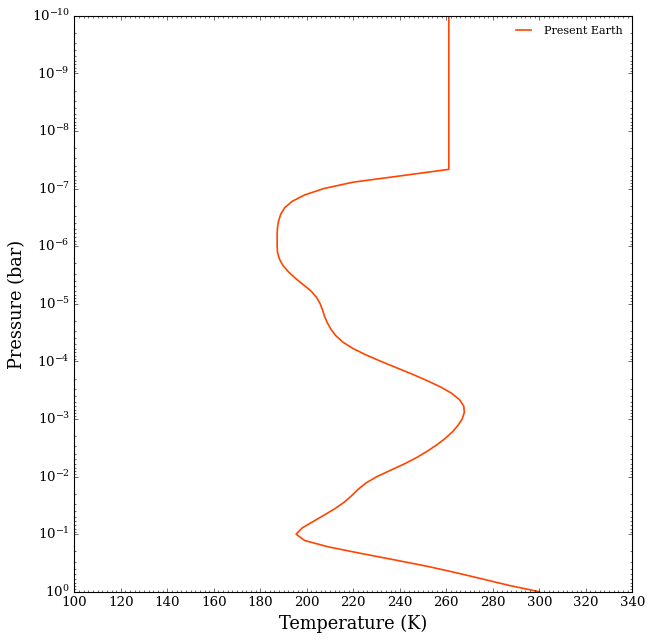

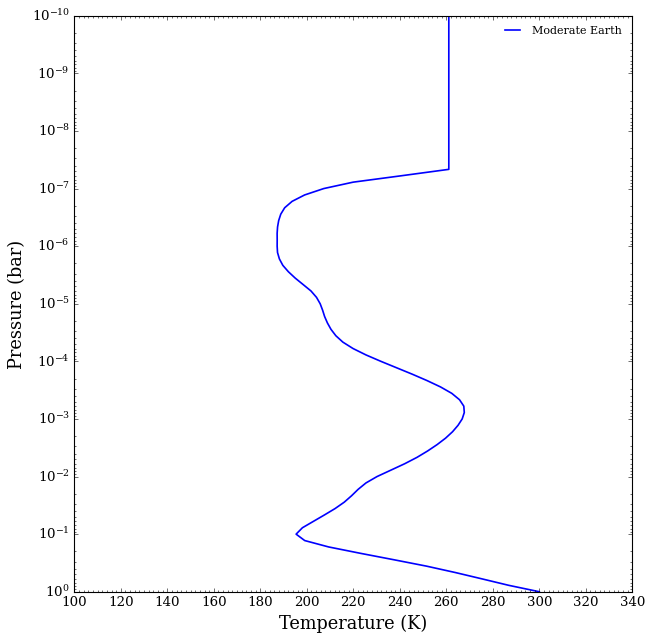

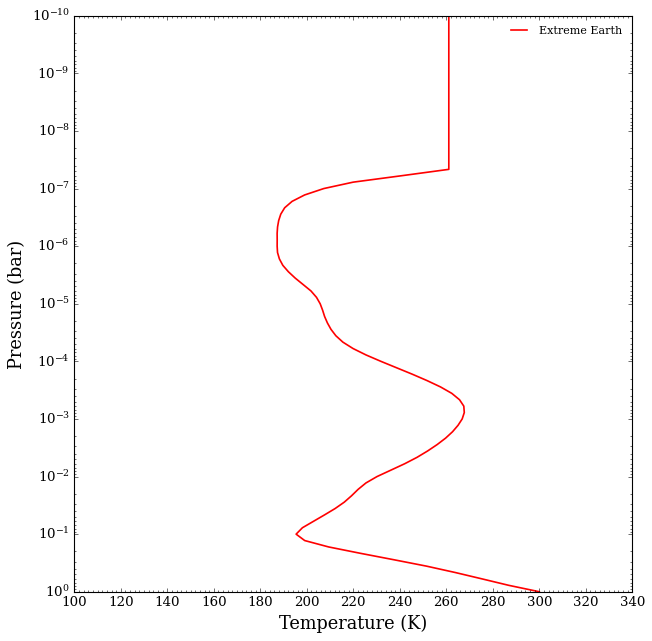

In [30]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem

# Generate the atmospheres
atmosphere_A0 = make_atmosphere(planet, model_1, P, P_ref, R_p_ref,
                               T_input = T_Modern, X_input = X_A0,    # Provide T and X directly here
                               P_surf = P_surf)                           # Also provide the surface pressure
atmosphere_A1 = make_atmosphere(planet, model_2, P, P_ref, R_p_ref,
                               T_input = T_Archean, X_input = X_A1,    # Provide T and X directly here
                               P_surf = P_surf)                             # Also provide the surface pressure
atmosphere_A2 = make_atmosphere(planet, model_3, P, P_ref, R_p_ref,
                               T_input = T_Moderate, X_input = X_A2,    # Provide T and X directly here
                               P_surf = P_surf)                             # Also provide the surface pressure
atmosphere_A3 = make_atmosphere(planet, model_4, P, P_ref, R_p_ref,
                               T_input = T_Extreme, X_input = X_A3,    # Provide T and X directly here
                               P_surf = P_surf)                             # Also provide the surface pressure


#***** Produce plots of atmospheric properties *****#

# Compare the P-T profiles first
fig_PT_1 = plot_PT(planet, model_1, atmosphere_A0, T_min = 100, T_max = 340,       # This demonstrates several plot customisation options
                   log_P_max = np.log10(P_surf), PT_label = 'Preagricultural Earth',
                   legend_location = 'upper right', colour = 'darkgreen')
fig_PT_2 = plot_PT(planet, model_2, atmosphere_A1, T_min = 100, T_max = 340,
                   log_P_max = np.log10(P_surf), PT_label = 'Present Earth',
                   legend_location = 'upper right', colour = 'orangered')
fig_PT_3 = plot_PT(planet, model_3, atmosphere_A2, T_min = 100, T_max = 340,
                   log_P_max = np.log10(P_surf), PT_label = 'Moderate Earth',
                   legend_location = 'upper right', colour = 'blue')
fig_PT_4 = plot_PT(planet, model_4, atmosphere_A3, T_min = 100, T_max = 340,
                   log_P_max = np.log10(P_surf), PT_label = 'Extreme Earth',
                   legend_location = 'upper right', colour = 'red')
#fig_geom_1 = plot_geometry(planet, star, model_1, atmosphere_1)   # This figure looks a little boring for a (tiny) Earth-like atmosphere!

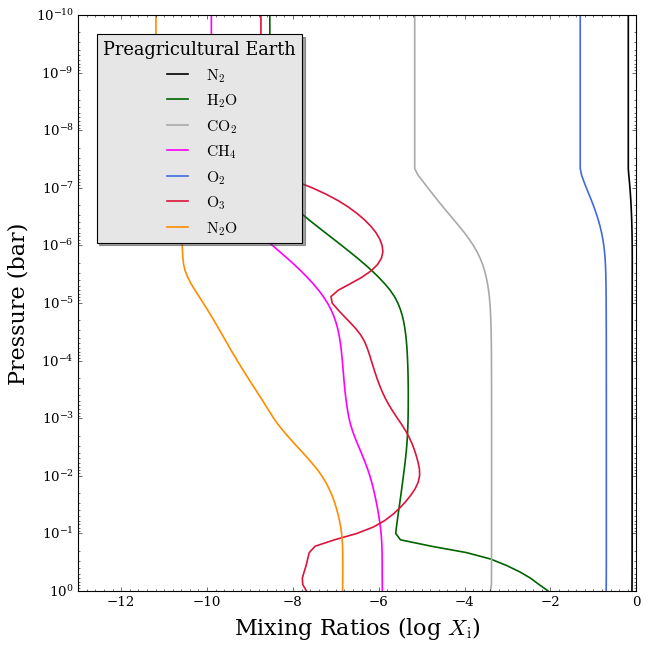

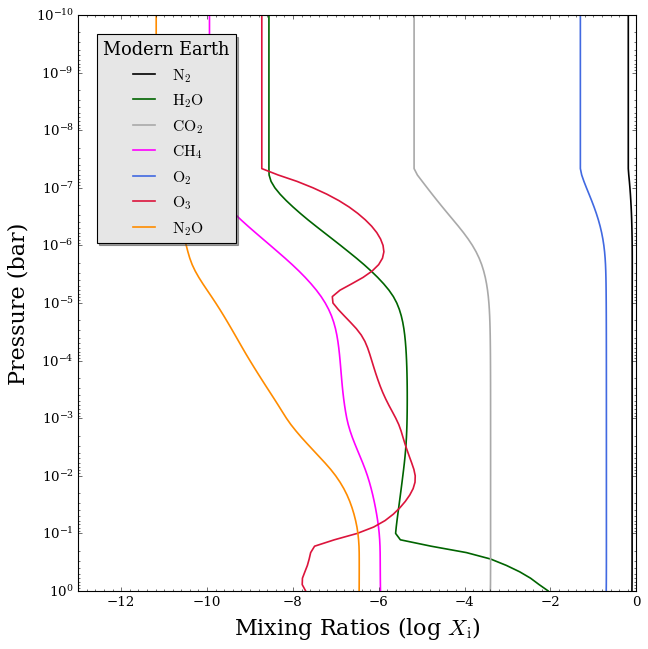

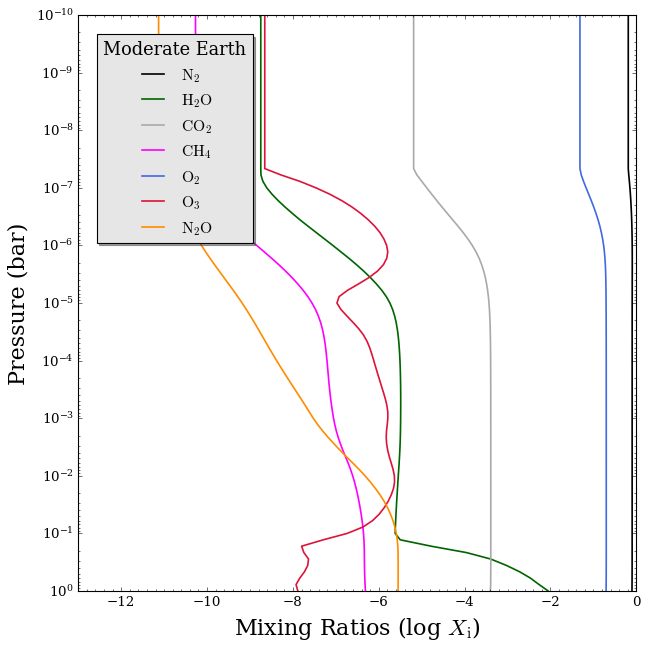

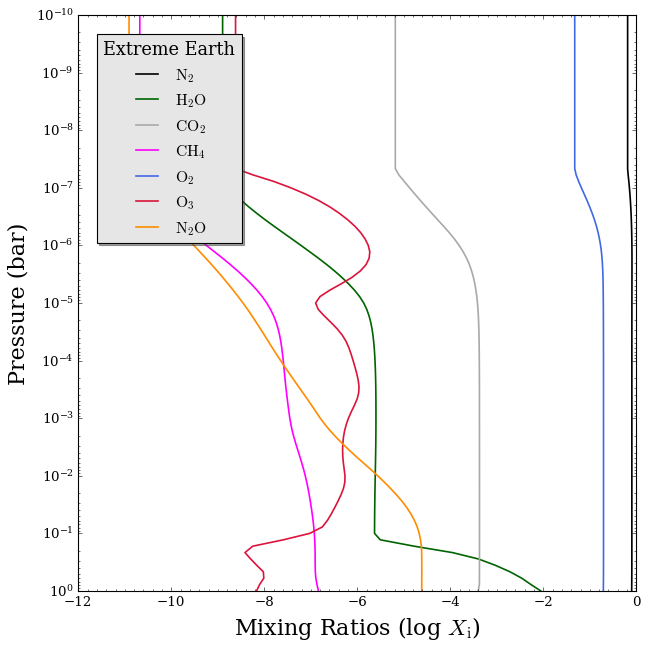

In [32]:
# Compare the mixing ratio profiles
fig_chem_1 = plot_chem(planet, model_1, atmosphere_A0, log_P_max = np.log10(P_surf),
                       legend_title = 'Preagricultural Earth', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                      'royalblue', 'crimson', 'darkorange', ])
fig_chem_2 = plot_chem(planet, model_2, atmosphere_A1, log_P_max = np.log10(P_surf),
                       legend_title = 'Modern Earth', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                      'royalblue', 'crimson', 'darkorange', ])
fig_chem_3 = plot_chem(planet, model_3, atmosphere_A2, log_P_max = np.log10(P_surf),
                       legend_title = 'Moderate Earth', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                      'royalblue', 'crimson', 'darkorange', ])
fig_chem_4 = plot_chem(planet, model_4, atmosphere_A3, log_P_max = np.log10(P_surf),
                       legend_title = 'Extreme Earth', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                       'royalblue', 'crimson', 'darkorange', ])


In [33]:
atmosphere_A0.keys()

dict_keys(['P', 'T', 'g', 'n', 'r', 'r_up', 'r_low', 'dr', 'P_surf', 'X', 'X_active', 'X_CIA', 'X_ff', 'X_bf', 'mu', 'N_sectors', 'N_zones', 'alpha', 'beta', 'phi', 'theta', 'phi_edge', 'theta_edge', 'dphi', 'dtheta', 'kappa_cloud_0', 'P_cloud', 'f_cloud', 'phi_cloud_0', 'theta_cloud_0', 'a', 'gamma', 'is_physical', 'mu_back', 'H', 'r_m', 'log_n_max', 'fractional_scale_height', 'aerosol_species', 'r_i_real', 'r_i_complex', 'log_X_Mie', 'P_cloud_bottom', 'kappa_cloud_eddysed', 'g_cloud_eddysed', 'w_cloud_eddysed', 'log_r_m_std_dev', 'f_both', 'f_aerosol_1', 'f_aerosol_2', 'f_clear'])

In [34]:
from POSEIDON.core import read_opacities, wl_grid_constant_R

#***** Wavelength grid *****#

wl_min = 0.6      # Minimum wavelength (um)
wl_max = 14.0     # Maximum wavelength (um)
R = 10000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # 100 K lower limit covers the TRAPPIST-1e P-T profile
T_fine_max = 400     # 300 K upper limit covers the TRAPPIST-1e P-T profile
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -10.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 0.0    # 1 bar is the surface pressure, so no need to go deeper
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Create opacity object (both models share the same molecules, so we only need one)
opac = read_opacities(model_1, wl, opacity_treatment, T_fine, log_P_fine,
                      opacity_database = 'High-T')

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
O2-O2 done
O2-CO2 done
O2-N2 done
H2O done
CO2 done
CH4 done
O2 done
O3 done
N2O done
Opacity pre-interpolation complete.


In [35]:
opac.keys()

dict_keys(['opacity_database', 'opacity_treatment', 'sigma_stored', 'CIA_stored', 'Rayleigh_stored', 'eta_stored', 'ff_stored', 'bf_stored', 'T_fine', 'log_P_fine', 'database_version', 'aerosol_stored'])

In [36]:
opac

{'opacity_database': 'High-T',
 'opacity_treatment': 'opacity_sampling',
 'sigma_stored': array([[[[2.00259801e-031, 2.43856621e-036, 5.99401176e-037, ...,
           7.07738122e-053, 2.89018775e-043, 5.48125690e-043],
          [2.60736512e-032, 1.10301139e-035, 3.00860462e-036, ...,
           4.20870639e-050, 3.35709685e-042, 6.36677289e-042],
          [4.76842816e-033, 3.87957843e-035, 1.15408569e-035, ...,
           8.63068624e-048, 2.59116687e-041, 4.91419093e-041],
          ...,
          [2.86393520e-029, 1.10101089e-030, 1.63861807e-031, ...,
           4.33549994e-035, 1.08800108e-033, 2.47138223e-033],
          [2.93209113e-029, 1.25184600e-030, 1.80058749e-031, ...,
           5.07737428e-035, 1.65801237e-033, 2.84249397e-033],
          [2.99834103e-029, 1.41423712e-030, 1.96926378e-031, ...,
           5.89941806e-035, 2.47399197e-033, 3.24654333e-033]],
 
         [[2.00259801e-031, 2.43856621e-036, 5.99401176e-037, ...,
           7.07738122e-053, 2.89018775e-043, 5

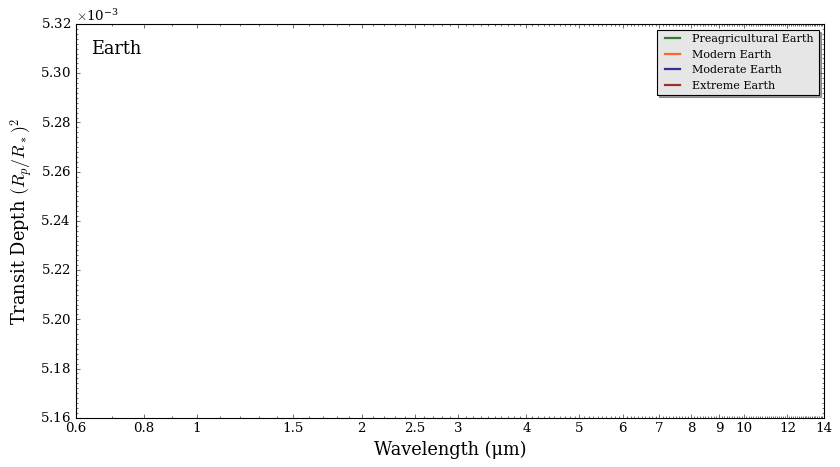

In [37]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Generate our first transmission spectrum
spectrum_A0 = compute_spectrum(planet, star, model_1, atmosphere_A0, opac, wl,
                                   spectrum_type = 'transmission')
spectrum_A1 = compute_spectrum(planet, star, model_2, atmosphere_A1, opac, wl,
                                    spectrum_type = 'transmission')
spectrum_A2 = compute_spectrum(planet, star, model_3, atmosphere_A2, opac, wl,
                                    spectrum_type = 'transmission')
spectrum_A3 = compute_spectrum(planet, star, model_4, atmosphere_A3, opac, wl,
                                    spectrum_type = 'transmission')


spectra = []   # Empty plot collection

# Add the two model spectra to the plot collection object
spectra = plot_collection(spectrum_A0, wl, collection = spectra)
spectra = plot_collection(spectrum_A1, wl, collection = spectra)
spectra = plot_collection(spectrum_A2, wl, collection = spectra)
spectra = plot_collection(spectrum_A3, wl, collection = spectra)

# Produce figure and save to file
fig_spec = plot_spectra(spectra, planet, R_to_bin = 100, plot_full_res = False,
                        y_min = 5.16e-3, y_max = 5.32e-3,
                        spectra_labels = ['Preagricultural Earth', 'Modern Earth', 'Moderate Earth', 'Extreme Earth'],
                        colour_list = ['darkgreen', 'orangered', 'darkblue', 'darkred'],
                        figure_shape = 'wide')   # Switch to a 'wide' format (16:9) for better viewing a long wavelength range